# Customer Segmentation

## 1️⃣ Introduction  

This dataset contains information about customers in a shopping mall, including features such as **Annual Income** and **Spending Score**.  

The goal is to **segment customers into distinct groups** based on their purchasing behavior, which can help businesses better understand their customer base and design targeted marketing strategies.  

### 🎯 Objectives  
- Explore the relationship between income and spending score.  
- Apply **clustering techniques** to group customers into meaningful segments.  
- Determine the **optimal number of clusters** using methods like the *Elbow Method* and *Silhouette Score*.  
- Visualize the clusters in **2D plots** for better interpretation.  
- *(Bonus)* Experiment with other clustering algorithms (e.g., **DBSCAN**) and analyze the **average spending per cluster**.  

## import libraries

In [185]:
# Data handling
import pandas as pd
import numpy as np
import math

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning (Scikit-learn)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

---

## 2️⃣ Data Loading & Cleaning

### Load the dataset and quick overview.

In [186]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [188]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Check for Duplicates and handle them if any

In [189]:
print(df.duplicated().sum())

0


### Check for missing values and handle them appropriately.

In [190]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Ensure correct data types for all columns.

In [191]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

---

## 3️⃣ Exploratory Data Analysis (EDA)

### **Univariate Analysis:** Visualize distributions of numerical features using histograms and boxplots.

In [192]:
numerical_cols = df.select_dtypes(include=['int64']).columns.drop('CustomerID').to_list()

# Automatically calculate rows and columns
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numerical_cols) / n_cols)

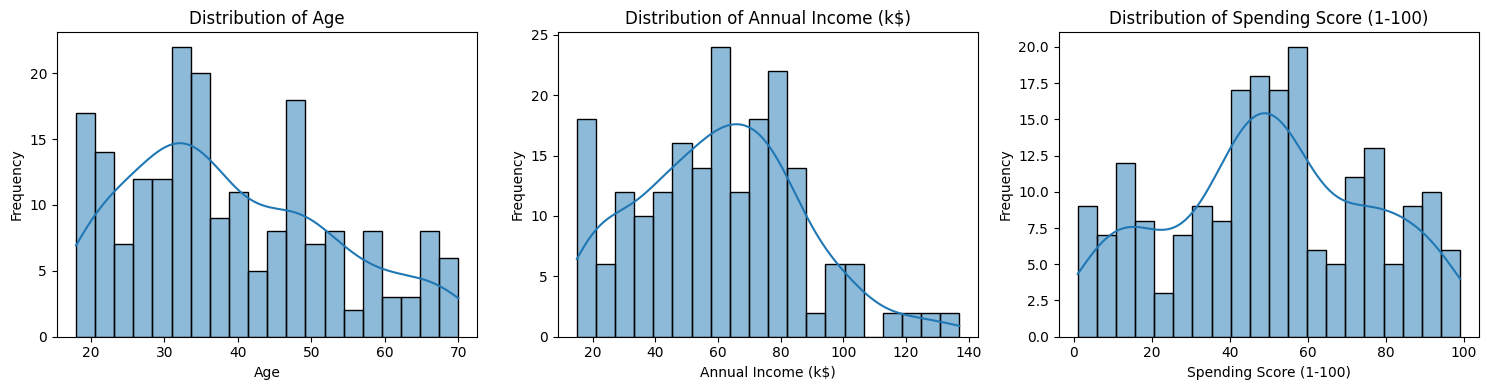

In [193]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove any empty subplots (if total plots < n_rows*n_cols)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

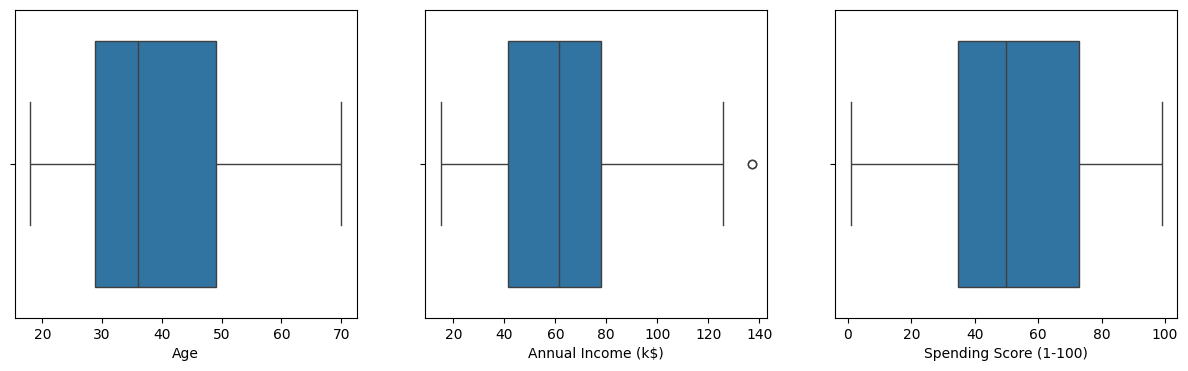

In [194]:
# Automatically calculate rows and columns
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])

# Remove any empty subplots (if total plots < n_rows*n_cols)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.show()

### **Bivariate Analysis:** Explore relationships between study hours and exam scores using scatter plots.

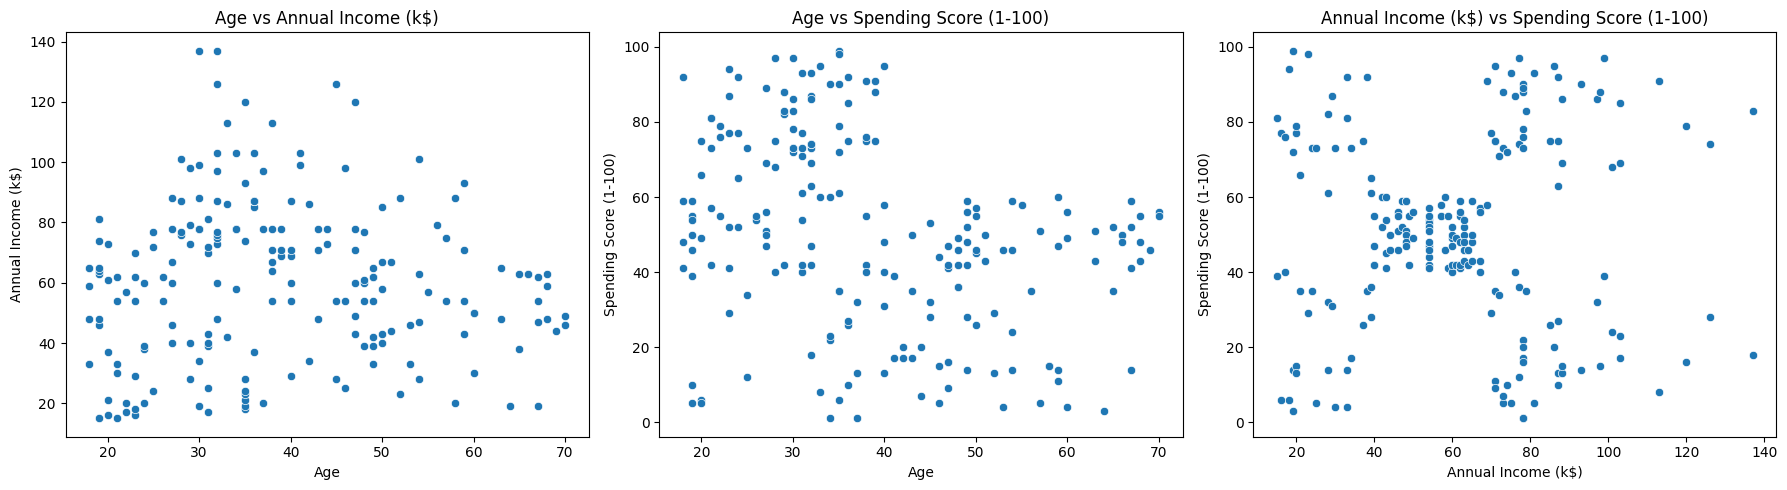

In [195]:
# Select numerical columns (excluding CustomerID since it's just an identifier)
numerical_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Generate all pairs of numerical columns
pairs = [(numerical_cols[i], numerical_cols[j]) 
         for i in range(len(numerical_cols)) 
         for j in range(i+1, len(numerical_cols))]

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(pairs) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    sns.scatterplot(x=df[x_col], y=df[y_col], ax=axes[i])
    axes[i].set_title(f"{x_col} vs {y_col}")

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Univariate Analysis (Categorical):** Explore the distribution of categorical features (e.g., Gender) using count plots.

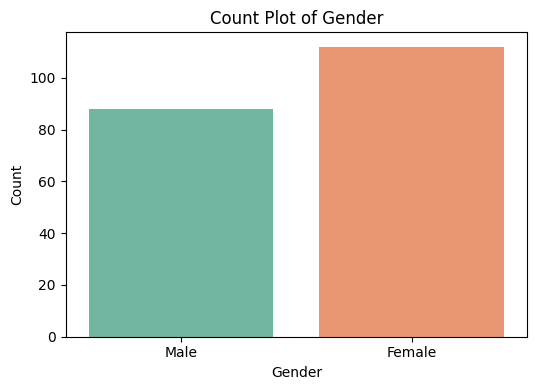

In [196]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()

# Automatically calculate rows and columns
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], hue=col, palette="Set2")
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")   # countplot = frequency, not "Exam Score"
    axes[i].tick_params(axis="x")  # rotate labels if too long

# Remove any empty subplots (if total plots < n_rows*n_cols)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### **Correlation Analysis:** Use a heatmap to detect correlations between features and the target variable.

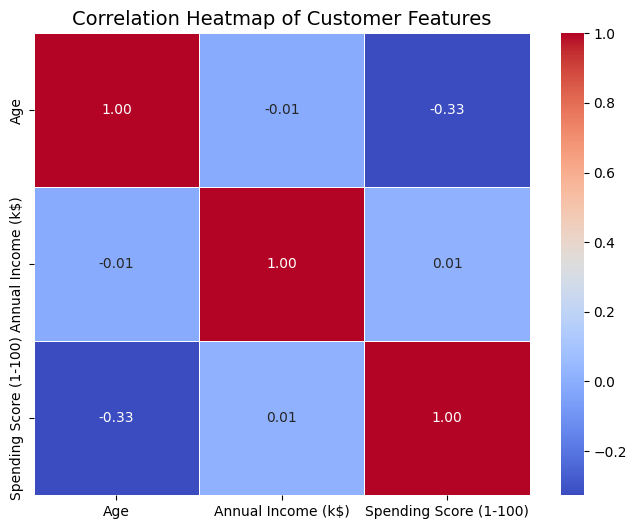

In [197]:
# Compute correlations only for numeric features (exclude CustomerID)
corr_matrix = df.drop(columns=["CustomerID"]).corr(numeric_only=True)

# Plot heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Customer Features", fontsize=14)
plt.show()

## 4️⃣ Feature Engineering

### Encoding categorical features

In [198]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


### Scaling

In [199]:
scaler = StandardScaler()
for col in numerical_cols:
    df_encoded[col] = scaler.fit_transform(df_encoded[[col]])

In [200]:
df_encoded.drop(columns='CustomerID', axis=1, inplace=True)
df_encoded.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,True
1,-1.281035,-1.738999,1.195704,True
2,-1.352802,-1.700830,-1.715913,False
3,-1.137502,-1.700830,1.040418,False
4,-0.563369,-1.662660,-0.395980,False


## 5️⃣ Model Building

### Detecting the best number of clusters

In [204]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assume df is loaded, X is your features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)  # NEW MODEL EACH TIME!
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}, inertia={kmeans.inertia_:.2f}")  # Print to spot increases

print("Full inertias list:", inertias)

k=1, inertia=400.00
k=2, inertia=269.69
k=3, inertia=157.70
k=4, inertia=108.92
k=5, inertia=65.57
k=6, inertia=55.06
k=7, inertia=44.86
k=8, inertia=37.23
k=9, inertia=32.39
k=10, inertia=29.98
Full inertias list: [400.00000000000006, 269.6910121927639, 157.70400815035944, 108.92131661364357, 65.56840815571681, 55.057348270385994, 44.86475569922556, 37.228187677585886, 32.39226763033117, 29.981897788243693]


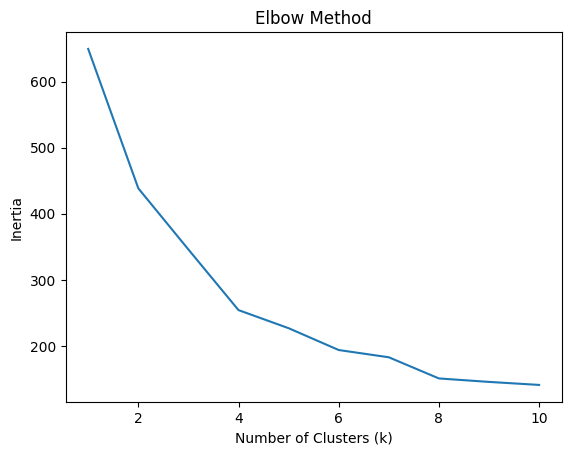

In [201]:
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(df_encoded)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Running the k-means clustering algorithm

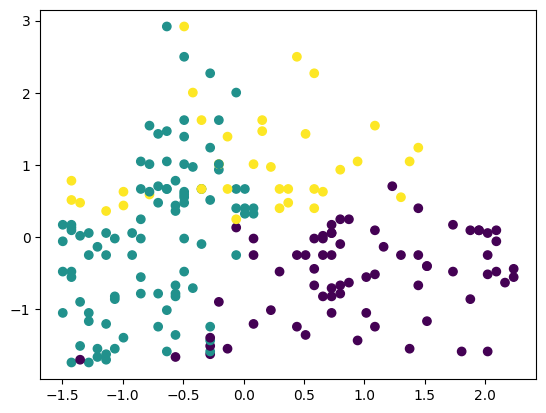

In [202]:
kmeans = KMeans(n_clusters=3, random_state = 0) 
kmeans.fit(df_encoded) 
labels = kmeans.predict(df_encoded) 
plt.scatter(df_encoded.iloc[:, 0], df_encoded.iloc[:, 1], c=labels) 
plt.show()

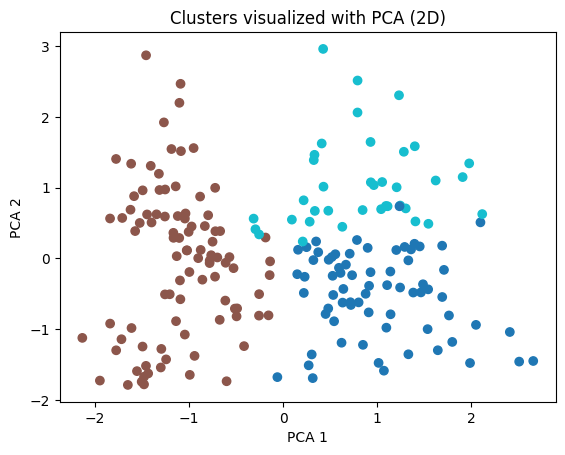

In [203]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(df_encoded)

plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="tab10")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters visualized with PCA (2D)")
plt.show()